In [1]:
%load_ext autoreload
%autoreload 2

# Exploratory Data Analysis — ConvFinQA Dataset
Goal: understand the structure and composition of the dataset before committing to a sample size and evaluation strategy.
Key questions:
   - How many records are in each split?
   - What's the Type I vs Type II breakdown?
   - How many turns do conversations have on average?
   - Are there any data quality issues we need to account for?

In [2]:
import json

with open("../data/convfinqa_dataset.json") as f:
    data = json.load(f)

Load the full dataset and flatten all splits into a single DataFrame.

We keep a 'split' column so we can filter to train/dev/test independently.

The features dict gives us pre-computed flags from Tomoro's cleaning process so we don't have to recompute them ourselves.

> Flatten all splits into one df for overview, keep split label

In [13]:
import pandas as pd

rows = []
for split in ["train", "dev", "test"]:
    for r in data.get(split, []):
        rows.append({
            "id":                   r["id"],
            "split":                split,
            "num_turns":            r["features"]["num_dialogue_turns"],
            "has_type2":            r["features"]["has_type2_question"],
            "has_duplicate_cols":   r["features"]["has_duplicate_columns"],
            "has_non_numeric":      r["features"]["has_non_numeric_values"],
        })

df = pd.DataFrame(rows)
dev = df[df["split"] == "dev"]

## Split sizes and Type I/II breakdown
We evaluate on dev only. Understanding the Type I/II ratio here is what determines our stratified sample proportions.
- Type I = simple single-thread conversations (one FinQA question decomposed)
- Type II = hybrid conversations (two FinQA questions interleaved) — harder, longer reasoning chains, more likely to see error propagation.

In [ ]:
print(df.groupby("split").size())

# type1 vs type2 breakdown per split
print(df.groupby(["split", "has_type2"]).size().unstack())

# Quick overview of the dev set.
print(f"\nDev set: {len(dev)} records")
print(f"Type I  (has_type2=False): {(~dev['has_type2']).sum()}")
print(f"Type II (has_type2=True) : {dev['has_type2'].sum()}")
print(f"Type II %: {dev['has_type2'].mean():.1%}")

split
dev       421
train    3037
dtype: int64
has_type2  False  True 
split                  
dev          300    121
train       2148    889

Dev set: 421 records
Type I  (has_type2=False): 300
Type II (has_type2=True) : 121
Type II %: 28.7%


## Turn count distribution
Important for two reasons:
1. Inference cost — more turns = more LLM calls per record
2. Difficulty — the paper (Figure 5) shows accuracy degrades on later turns due to longer reasoning chains. We want to know how many records have 5+ turns since those are the hardest cases.

> Mean ~3.5 turns, max 8. The long tail (6-8 turns) is where timeouts occur on local hardware — noted as an infrastructure limitation in the report. — important for understanding eval cost

In [15]:
print(dev["num_turns"].describe())
print(dev["num_turns"].value_counts().sort_index())

count    421.000000
mean       3.539192
std        1.252239
min        2.000000
25%        2.000000
50%        4.000000
75%        5.000000
max        8.000000
Name: num_turns, dtype: float64
num_turns
2    116
3     94
4    103
5     88
6     17
7      2
8      1
Name: count, dtype: int64


Quick check on dupes and non-numeric cols

In [16]:
print(f"\nhas_duplicate_cols : {dev['has_duplicate_cols'].sum()}")
print(f"has_non_numeric    : {dev['has_non_numeric'].sum()}")


has_duplicate_cols : 17
has_non_numeric    : 32


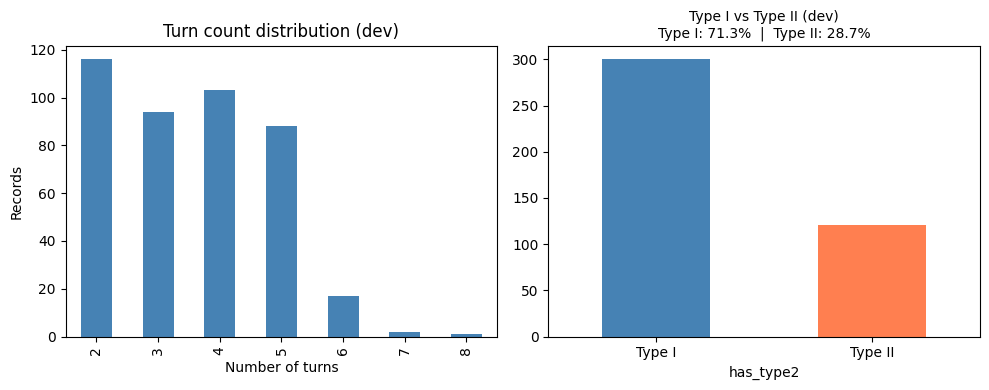

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# turn distribution
dev["num_turns"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Turn count distribution (dev)")
axes[0].set_xlabel("Number of turns")
axes[0].set_ylabel("Records")

# type split
dev["has_type2"].value_counts().plot(
    kind="bar", ax=axes[1], color=["steelblue", "coral"]
)
axes[1].set_title("Type I vs Type II (dev)")
axes[1].set_xticklabels(["Type I", "Type II"], rotation=0)

type1_pct = (~dev["has_type2"]).mean() * 100
type2_pct = dev["has_type2"].mean() * 100
axes[1].set_title(
    f"Type I vs Type II (dev)\n"
    f"Type I: {type1_pct:.1f}%  |  Type II: {type2_pct:.1f}%",
    fontsize=10
)

plt.tight_layout()
plt.show()

When we do split the test set later we have to maintain this type I vs type II distribution

# Sanity test of code from src folder

In [3]:
import sys

sys.path.append("../")

from src.prompt import build_messages, format_table

record = data["train"][0]
doc      = record["doc"]
dialogue = record["dialogue"]

In [4]:
print(format_table(doc["table"]))

| Row | Year ended June 30, 2009 | 2008 | 2007 |
|---||---||---||---|
| net income | 103102.0 | 104222.0 | 104681.0 |
| non-cash expenses | 74397.0 | 70420.0 | 56348.0 |
| change in receivables | 21214.0 | -2913.0 | -28853.0 |
| change in deferred revenue | 21943.0 | 5100.0 | 24576.0 |
| change in other assets and liabilities | -14068.0 | 4172.0 | 17495.0 |
| net cash from operating activities | 206588.0 | 181001.0 | 174247.0 |


Inspect the prompt for each turn (no API call yet)

In [5]:
for turn_index in range(dialogue["num_turns"] if "num_turns" in record.get("features", {}) 
                        else len(dialogue["conv_questions"])):
    messages = build_messages(
        pre_text      = doc["pre_text"],
        post_text     = doc["post_text"],
        table         = doc["table"],
        questions     = dialogue["conv_questions"],
        prior_answers = dialogue["executed_answers"][:turn_index],  # gold-chain mode
        turn_index    = turn_index,
    )
    print(f"\n{'='*60}")
    print(f"TURN {turn_index + 1}: {dialogue['conv_questions'][turn_index]}")
    print(f"{'='*60}")
    print(messages[1]["content"])  # user prompt only, system is noise for inspection
    print(f"\nGOLD ANSWER: {dialogue['executed_answers'][turn_index]}")


TURN 1: what is the net cash from operating activities in 2009?
## Financial document

### Text (before table)
26 | 2009 annual report in fiscal 2008 , revenues in the credit union systems and services business segment increased 14% ( 14 % ) from fiscal 2007 . all revenue components within the segment experienced growth during fiscal 2008 . license revenue generated the largest dollar growth in revenue as episys ae , our flagship core processing system aimed at larger credit unions , experienced strong sales throughout the year . support and service revenue , which is the largest component of total revenues for the credit union segment , experienced 34 percent growth in eft support and 10 percent growth in in-house support . gross profit in this business segment increased $ 9344 in fiscal 2008 compared to fiscal 2007 , due primarily to the increase in license revenue , which carries the highest margins . liquidity and capital resources we have historically generated positive cash flow

In [4]:
from src.llm_utils import call_llm

In [ ]:
# try on turn 0 first
messages = build_messages(
    pre_text      = doc["pre_text"],
    post_text     = doc["post_text"],
    table         = doc["table"],
    questions     = dialogue["conv_questions"],
    prior_answers = [],
    turn_index    = 0,
)

response = call_llm(messages)

In [7]:
from IPython.display import Markdown

display(Markdown(response))

STEPS:
1. Locate the row labeled "net cash from operating activities" in the provided table.
2. Identify the column corresponding to the year ended June 30, 2009.
3. Extract the value found at the intersection of the row and column, which is 206588.0.
4. Cross-reference with the text after the table which states "cash provided by operations increased $ 25587 to $ 206588 for the fiscal year ended june 30 , 2009".

ANSWER: 206588.0

Run the full conversation in gold-chain mode

In [8]:
import re

prior_answers = []

for i, question in enumerate(dialogue["conv_questions"]):
    messages = build_messages(
        pre_text      = doc["pre_text"],
        post_text     = doc["post_text"],
        table         = doc["table"],
        questions     = dialogue["conv_questions"],
        prior_answers = prior_answers,
        turn_index    = i,
    )
    
    raw = call_llm(messages)    
    match = re.search(r"ANSWER:\s*(.+)", raw)
    predicted = match.group(1).strip() if match else "PARSE_ERROR"
    
    print(f"\nQ{i+1}: {question}")
    print(f"  Predicted : {predicted}")
    print(f"  Gold      : {dialogue['executed_answers'][i]}")
    print(f"  Scratchpad:\n{raw}")
    
    # gold-chain: feed gold answer forward, not predicted
    prior_answers.append(str(dialogue["executed_answers"][i]))


Q1: what is the net cash from operating activities in 2009?
  Predicted : 206588.0
  Gold      : 206588.0
  Scratchpad:
STEPS:
1. Locate the row labeled "net cash from operating activities" in the provided table.
2. Identify the column corresponding to the year ended June 30, 2009.
3. Extract the value found at the intersection of the row and column, which is 206588.0.
4. Cross-reference with the text after the table which states "cash provided by operations increased $ 25587 to $ 206588 for the fiscal year ended june 30 , 2009".

ANSWER: 206588.0

Q2: what about in 2008?
  Predicted : 181001.0
  Gold      : 181001.0
  Scratchpad:
STEPS:
1. Identify the metric requested based on the previous turn (net cash from operating activities) and the target year (2008).
2. Locate the table in the financial document containing cash flow data for years ended June 30.
3. Find the row labeled "net cash from operating activities".
4. Find the column labeled "2008".
5. Extract the value at the inters

In [5]:
from src.eval import evaluate_record

In [ ]:
result = evaluate_record(
    record           = data["train"][0],
    call_llm         = call_llm,
    mode             = "gold",
    build_messages_fn= build_messages,
)

print(f"Exe acc (record 0): {result.exe_acc:.2%}")
for t in result.turns:
    status = "✓" if t.num_match else "✗"
    print(f"  Turn {t.turn_index+1} {status}  pred={t.predicted!r:>12}  gold={t.gold_executed}")

Exe acc (record 0): 100.00%
  Turn 1 ✓  pred=  '206588.0'  gold=206588.0
  Turn 2 ✓  pred=  '181001.0'  gold=181001.0
  Turn 3 ✓  pred=   '25587.0'  gold=25587.0
  Turn 4 ✓  pred=   '0.14136'  gold=0.14136


AWESOME we got all 4 turns correct

# Evaluation

In [6]:
from pathlib import Path

from src.pipeline import run_pipeline

## Smoke test: Runs against the first 5 records

In [8]:
results, metrics = run_pipeline(
    records      = data["dev"],          # use dev, not train, for eval
    call_llm     = call_llm,
    output_path  = Path("../outputs/results_gold_dev.json"),
    mode         = "gold",
    max_records  = 5,
    resume       = True,
)

print(f"\n{'='*40}")
print(f"Exe acc:            {metrics['exe_acc']:.2%}")
print(f"Conv acc:           {metrics['conv_acc']:.2%}")
print(f"Parse error rate:   {metrics['parse_error_rate']:.2%}")
print("\nAccuracy by turn position:")
for pos, acc in metrics["acc_by_turn_position"].items():
    bar = "█" * int(acc * 20)
    print(f"  Turn {pos+1}: {acc:.2%} {bar}")

2026-03-28 15:20:03,133 - src.logger - INFO - Running 5 records in mode='gold'
Evaluating [gold]:   0%|          | 0/5 [00:00<?, ?it/s]

2026-03-28 15:52:11,784 - src.logger - WARNING - Failed on record Single_MRO/2007/page_134.pdf-1: Request timed out.
Evaluating [gold]: 100%|██████████| 5/5 [1:12:54<00:00, 874.94s/it]


Exe acc:            90.91%
Conv acc:           66.67%
Parse error rate:   0.00%

Accuracy by turn position:
  Turn 1: 100.00% ████████████████████
  Turn 2: 100.00% ████████████████████
  Turn 3: 50.00% ██████████
  Turn 4: 100.00% ████████████████████
  Turn 5: 100.00% ████████████████████


In [12]:
import json

import pandas as pd

with open("../outputs/results_gold_dev.json") as f:
    raw = json.load(f)

rows = []
for record in raw:
    for t in record["turns"]:
        rows.append({
            "record_id":   record["record_id"],
            "turn_index":  t["turn_index"],
            "question":    t["question"],
            "predicted":   t["predicted"],
            "gold":        t["gold_executed"],
            "num_match":   t["num_match"],
            "em":          t["em"],
            "parse_error": t["parse_error"],
        })

df = pd.DataFrame(rows)

# the one failure — inspect it
print(df[~df["num_match"]][["record_id","turn_index","question","predicted","gold"]])

# turn position accuracy
print(df.groupby("turn_index")["num_match"].mean())

                       record_id  turn_index  \
8  Single_UNP/2008/page_77.pdf-2           2   

                                            question predicted  gold  
8  so what was the difference between the two years?      10.0 -10.0  
turn_index
0    1.0
1    1.0
2    0.5
3    1.0
4    1.0
Name: num_match, dtype: float64
